# POLITECNICO DI MILANO 1863

## Course: Embedded and Edge Artificial Intelligence  
## Professor: Prof. Manuel Roveri  
## Academic Year: 2025/2026  


---
**Topic:** Lab 4 - Human Activity Recognition (HAR) on Edge Devices  
**Objective:** Training an FFNN for activity classification and assessing memory demand.
---

1. Environment Setup
We start by importing the necessary libraries for data processing, neural network training, and visualization.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
SEED = 1337
np.random.seed(SEED)
tf.random.set_seed(SEED)

2. Synthetic Data Generation with Distinct Distributions
We generate 4 classes of synthetic IMU data. Unlike simple noise, we assign a specific statistical "signature" (mean μ and variance σ) to each class to ensure they are separable in the feature space.

In [2]:
SAMPLES_PER_CLASS = 1500
FEATURES = 300
CLASSES = 4
class_names = ['Sitting', 'Walking', 'Running', 'Standing']
colors = ['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e']

x_list, y_list = [], []

# Class 0: Sitting - Low magnitude, very stable
x_list.append(np.random.normal(loc=0.1, scale=0.05, size=(SAMPLES_PER_CLASS, FEATURES)))
# Class 1: Walking - Medium magnitude, rhythmic noise
x_list.append(np.random.normal(loc=0.3, scale=0.15, size=(SAMPLES_PER_CLASS, FEATURES)))
# Class 2: Running - High magnitude, high variance/noise
x_list.append(np.random.normal(loc=0.4, scale=0.2, size=(SAMPLES_PER_CLASS, FEATURES)))
# Class 3: Standing - Low magnitude, slightly noisier than sitting
x_list.append(np.random.normal(loc=0.15, scale=0.15, size=(SAMPLES_PER_CLASS, FEATURES)))

for i in range(CLASSES):
    y_list.append(np.full(SAMPLES_PER_CLASS, i))

x_values = np.concatenate(x_list).astype(np.float32)
y_values = np.concatenate(y_list)

# Data Splitting: 60% Train, 20% Val, 20% Test
indices = np.arange(x_values.shape[0])
np.random.shuffle(indices)
x_values, y_values = x_values[indices], y_values[indices]

train_split = int(0.6 * len(x_values))
test_split = int(0.2 * len(x_values) + train_split)

x_train, x_validate, x_test = np.split(x_values, [train_split, test_split])
y_train, y_validate, y_test = np.split(y_values, [train_split, test_split])

3. Data Visualization
Visualizing the data is crucial to understand the Inherent Risk (overlap between classes) and the nature of Noise Affected signals.

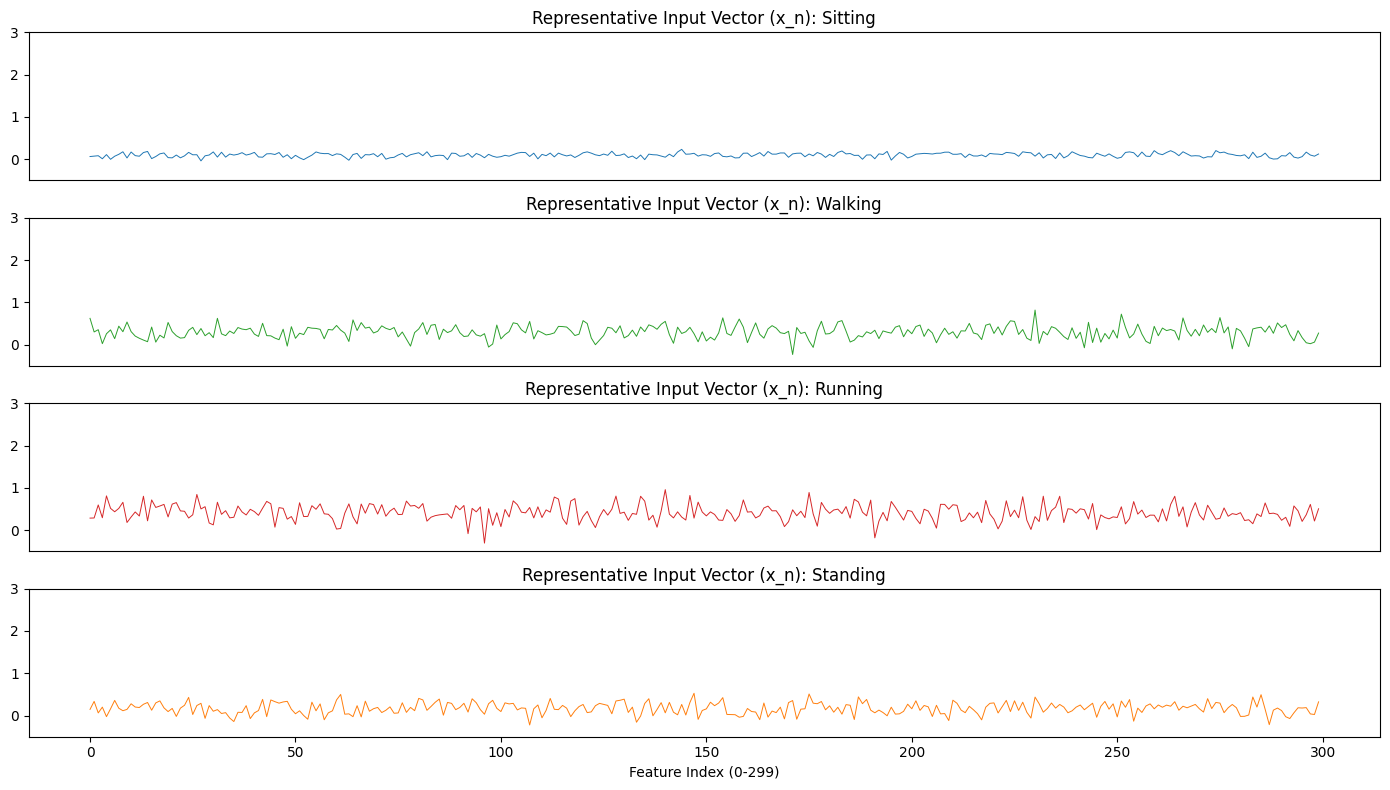

In [3]:
# Visualization: Signal Profiles
plt.figure(figsize=(14, 8))
for i in range(CLASSES):
    plt.subplot(4, 1, i+1)
    plt.plot(x_list[i][0], color=colors[i], linewidth=0.7)
    plt.title(f'Representative Input Vector (x_n): {class_names[i]}')
    plt.ylim(-0.5, 3.0)
    if i < 3: plt.xticks([])
plt.xlabel('Feature Index (0-299)')
plt.tight_layout()
plt.show()

4. Model Definition and Memory Analysis
We implement a Feed-Forward Neural Network (FFNN).

In [4]:
model = models.Sequential([
    # First Hidden Layer: 64 neurons (ReLU)
    layers.Dense(64, activation='relu', input_shape=(FEATURES,)),
    # Second Hidden Layer: 32 neurons (ReLU)
    layers.Dense(32, activation='relu'),
    # Output Layer: 4 classes (Softmax)
    layers.Dense(CLASSES, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        19,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,476 (83.89 KB)

 Trainable params: 21,476 (83.89 KB)

 Non-trainable params: 0 (0.00 B)

5. Training the Network
The training phase follows the supervised learning paradigm where the training algorithm minimizes the loss function E(w). The model updates its weights by taking steps in the direction of the negative gradient −∇E(w).

Epoch 1/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3853 - loss: 1.1746 - val_accuracy: 0.5733 - val_loss: 1.0186
Epoch 2/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7089 - loss: 0.7908 - val_accuracy: 0.8483 - val_loss: 0.6564
Epoch 3/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8603 - loss: 0.4923 - val_accuracy: 0.8650 - val_loss: 0.4471
Epoch 4/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9250 - loss: 0.3093 - val_accuracy: 0.8350 - val_loss: 0.3589
Epoch 5/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9531 - loss: 0.2072 - val_accuracy: 0.9567 - val_loss: 0.1939
Epoch 6/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9664 - loss: 0.1468 - val_accuracy: 0.9892 - val_loss: 0.1252
Epoch 7/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9864 - loss: 0.0990 - val_accuracy: 0.9850 - val_loss: 0.1024
Epoch 8/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9950 - loss: 0.0668 - val_accuracy: 0.

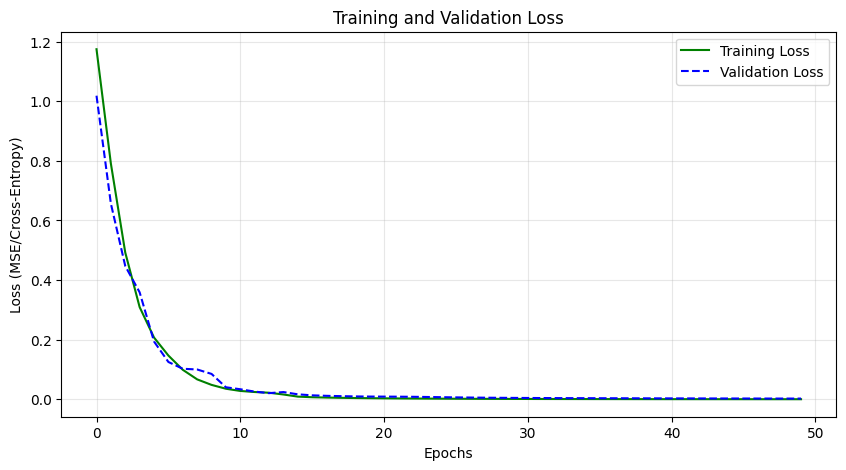

In [5]:
# 5.1 Training configuration (Slide 71)
# We use 'epochs' to define the number of iterations over the training set
# and 'batch_size' to define the number of samples processed before updating weights
history = model.fit(x_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_data=(x_validate, y_validate),
                    verbose=1)

# 5.2 Visualization of training and validation loss (Slide 72)
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', color='green')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue', linestyle='--')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE/Cross-Entropy)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

6. Model Evaluation and Testing
After training, we evaluate the model on the Test Set—data that the network has never seen before—to estimate its real-world performance.

In [6]:
# 6.1 Performance on the Test Set (Slide 77)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 100.00%
Test Loss: 0.0026


7. Confusion Matrix Analysis
To ensure that accuracy is not misleading (especially if classes were imbalanced), we use a Confusion Matrix to map true classes against predicted classes.

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


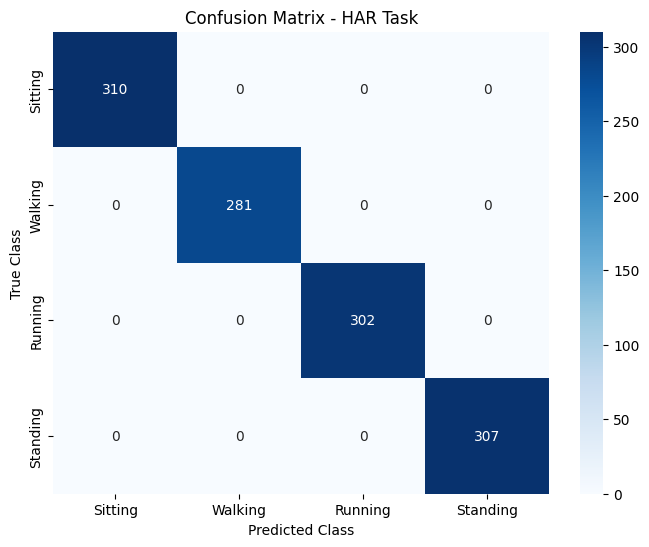

In [7]:
# 7.1 Generate predictions for the test set (Slide 77)
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 7.2 Compute the Confusion Matrix (Slide 40, 45)
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix - HAR Task')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

8. Experiment: Feature Engineering vs. Raw Data
In this section, we test if extracting high-level statistical features can improve the model's stability and reduce memory demand compared to using raw time-series data. By reducing the input size (h), we aim to minimize the Estimation Risk (overfitting) observed in the previous run.

8.1 Feature Extraction Function

Instead of feeding 300 raw samples, we transform each window into a 6-element vector containing: Mean, Standard Deviation, Maximum, Minimum, Range, and Root Mean Square (RMS).

In [8]:
def extract_features(data):
    """
    Transforms raw time-series windows into a reduced feature space.
    Reduces input dimensionality from 300 to 6.
    """
    features = []
    for sample in data:
        f_mean = np.mean(sample)
        f_std = np.std(sample)
        f_max = np.max(sample)
        f_min = np.min(sample)
        f_range = f_max - f_min
        f_rms = np.sqrt(np.mean(sample**2))

        features.append([f_mean, f_std, f_max, f_min, f_range, f_rms])
    return np.array(features)

# Apply extraction to all dataset splits
x_train_feat = extract_features(x_train)
x_validate_feat = extract_features(x_validate)
x_test_feat = extract_features(x_test)

print(f"New Input Shape: {x_train_feat.shape[1]} features")

New Input Shape: 6 features


8.2 Model Redefinition for Reduced Input

We keep the hidden layers (64, 32) the same to observe how the change in input dimensionality (h) affects the Memory Demand and the total number of parameters.

In [9]:
# Define the new model with a smaller input layer (h=6)
model_feat = models.Sequential([
    # Input layer shape changed to 6
    layers.Dense(64, activation='relu', input_shape=(x_train_feat.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(CLASSES, activation='softmax')
])

model_feat.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# Display updated summary to compare parameter counts
model_feat.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,660 (10.39 KB)

 Trainable params: 2,660 (10.39 KB)

 Non-trainable params: 0 (0.00 B)

8.3 Training with Features

We monitor the Loss curve again. Reducing the input size often leads to more stable training and less overfitting, as the model has fewer "unnecessary" parameters to fit the training noise.

Epoch 1/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2761 - loss: 1.2076 - val_accuracy: 0.4233 - val_loss: 1.0496
Epoch 2/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6786 - loss: 0.8369 - val_accuracy: 0.8050 - val_loss: 0.6147
Epoch 3/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9061 - loss: 0.4452 - val_accuracy: 0.9583 - val_loss: 0.3273
Epoch 4/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9847 - loss: 0.2506 - val_accuracy: 0.9967 - val_loss: 0.1947
Epoch 5/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9967 - loss: 0.1497 - val_accuracy: 0.9992 - val_loss: 0.1165
Epoch 6/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9986 - loss: 0.0910 - val_accuracy: 0.9992 - val_loss: 0.0725
Epoch 7/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9986 - loss: 0.0585 - val_accuracy: 1.0000 - val_loss: 0.0483
Epoch 8/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9992 - loss: 0.0401 - val_accuracy: 1.

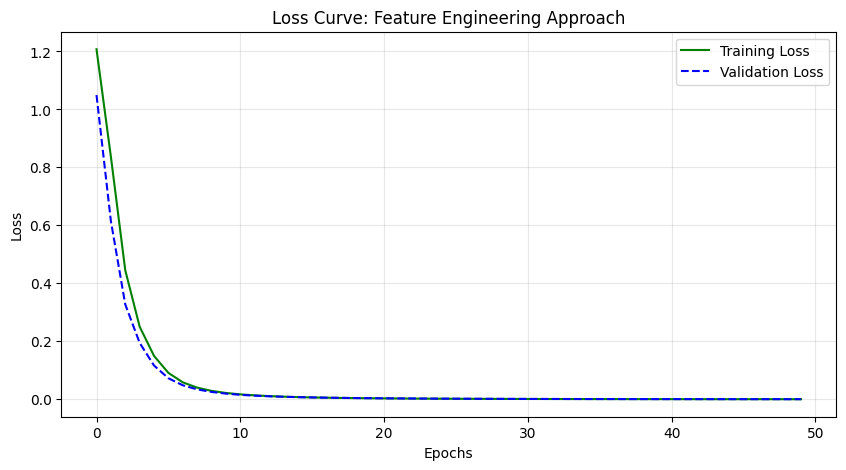

In [10]:
# Train the model using the engineered features
history_feat = model_feat.fit(x_train_feat, y_train,
                              epochs=50,
                              batch_size=32,
                              validation_data=(x_validate_feat, y_validate),
                              verbose=1)

# Visualization of Loss curves to check for overfitting
plt.figure(figsize=(10, 5))
plt.plot(history_feat.history['loss'], label='Training Loss', color='green')
plt.plot(history_feat.history['val_loss'], label='Validation Loss', color='blue', linestyle='--')
plt.title('Loss Curve: Feature Engineering Approach')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

8.4 Final Evaluation and Confusion Matrix

We assess if the model can still distinguish activities like "Sitting" and "Standing" using only 6 features.

Test Accuracy (with Engineered Features): 100.00%
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


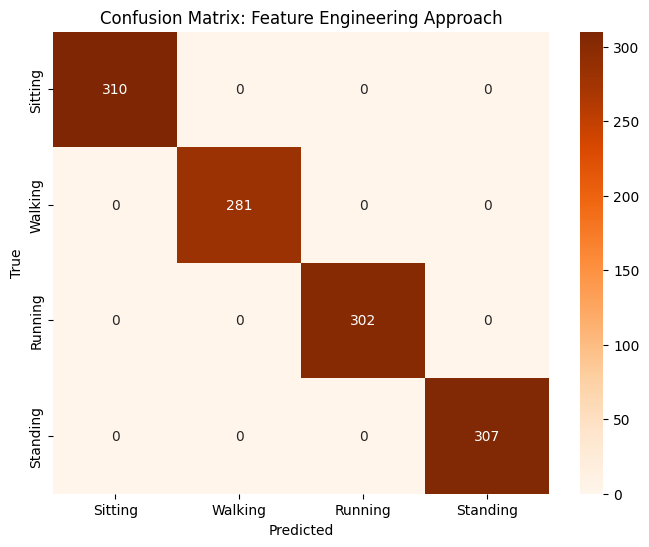

In [11]:
# Final Accuracy on the Test Set
test_loss_feat, test_acc_feat = model_feat.evaluate(x_test_feat, y_test, verbose=0)
print(f"Test Accuracy (with Engineered Features): {test_acc_feat*100:.2f}%")

# Generate the Confusion Matrix to inspect class separation
y_pred_feat = np.argmax(model_feat.predict(x_test_feat), axis=1)
cm_feat = confusion_matrix(y_test, y_pred_feat)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_feat, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Feature Engineering Approach')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()